# Stochastic Discount Factor for ETF Rotation

**Purpose.** Evaluate the stochastic discount factor (SDF) beta network as a predictor of 21-day
ETF returns using the fixed production checkpoint and point-in-time macro context.

**Learning objectives**

- distinguish the SDF's moment-pricing objective from its predictive beta-network output;
- trace the 11 macro inputs from ALFRED initial releases to one-day-lagged decision-time values;
- apply a checkpoint fixed before validation results are inspected; and
- compute rank IC within each validation date before averaging across time.

**Book reference.** Chapter 14, Section 14.7, "The stochastic discount factor and the
supervised autoencoder models."

**Prerequisites.** The ETF feature and label pipeline, eight purged walk-forward folds, the local
ALFRED initial-release parquet, and the latent-factor model configuration.

In [1]:
"""Evaluate the ETF stochastic discount factor through the shared model runner."""

import warnings

# Load PyTorch's bundled CUDA runtime before other ML4T libraries.
import torch  # noqa: F401

# isort: split
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython import get_ipython
from IPython.display import Markdown, display
from ml4t.diagnostic.metrics import compute_ic_uncertainty, cross_sectional_ic_series

from case_studies.utils.latent_factors.case_study import (
    configured_models,
    load_case_study_context,
    run_case_study_model,
)
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title, zero_line

warnings.filterwarnings("ignore")
shell = get_ipython()
if shell is not None:
    shell.run_line_magic("matplotlib", "inline")

In [2]:
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
N_FACTORS = 5
N_EPOCHS = 50
USE_CACHE = True
FORCE_RETRAIN = False
MAX_FOLDS = 0
MAX_VARIANT_LABELS = -1
USE_MACRO = True
MODEL_NAME = "sdf"
SEED = 42

In [3]:
REPORTING_CHECKPOINT = 1280
HORIZON = 21
set_global_seeds(SEED)

## Establish the point-in-time evaluation contract

Nine source series come from their first ALFRED vintages; two yield-curve spreads are computed
from those same releases. A value dated *t* becomes available to an ETF decision only on *t + 1*
and is then aligned backward. This prevents later revisions and same-close availability from
entering the direct SDF macro context.

The direct macro panel begins on 2010-11-23, one day after first-release VIX coverage starts. The
registered identity also seals the complete financial, model-based, label, and setup inputs. The
financial feature set still includes three finalized-FRED yield-curve variables, so the result is
not a fully vintage-clean live estimate; their exact materialized content is nevertheless fixed by
the modeling-input digest below.

In [4]:
context = load_case_study_context(
    CASE_STUDY_ID,
    primary_label=PRIMARY_LABEL,
    max_symbols=MAX_SYMBOLS,
    max_folds=MAX_FOLDS,
    max_variant_labels=MAX_VARIANT_LABELS,
    use_macro=USE_MACRO,
)
assert MODEL_NAME in configured_models(context)

input_identity = context.input_data_spec
macro_identity = context.macro_context_spec

assert input_identity["version"] == "v1"
assert macro_identity is not None
assert macro_identity["source"] == "alfred_initial_release"
assert macro_identity["policy"] == "alfred_initial_release_close_lagged"
assert macro_identity["version"] == "v1"
assert macro_identity["availability_lag_days"] == 1
assert macro_identity["alignment"] == "backward_asof"
assert len(macro_identity["series"]) == 11
assert macro_identity["coverage_start"] == "2010-11-23"

pl.DataFrame(
    {
        "input_version": [input_identity["version"]],
        "modeling_input_digest": [input_identity["input_digest"]],
        "macro_source": [macro_identity["source"]],
        "macro_policy": [macro_identity["policy"]],
        "macro_series": [len(macro_identity["series"])],
        "macro_digest": [macro_identity["input_digest"]],
    }
)

input_version,modeling_input_digest,macro_source,macro_policy,macro_series,macro_digest
str,str,str,str,i64,str
"""v1""","""sha256:8384ded464c95f36b9baff0…","""alfred_initial_release""","""alfred_initial_release_close_l…",11,"""sha256:8733d34952381381a665364…"


## Run walk-forward validation

Checkpoint 1280 is the end of the configured conditional schedule and is fixed before validation
results are examined. The shared runner loads an exact specification match when one is available;
otherwise, it trains and registers the same model specification. The input and macro identities
above are part of that cache key.

In [5]:
result = run_case_study_model(
    context,
    model_name=MODEL_NAME,
    notebook="11d_stochastic_discount_factor",
    n_factors=N_FACTORS,
    n_epochs=N_EPOCHS,
    use_cache=USE_CACHE,
    force_retrain=FORCE_RETRAIN,
    reporting_epoch=REPORTING_CHECKPOINT,
)

assert result["model_results"][0]["best_epoch"] == REPORTING_CHECKPOINT
assert result["fold_metrics"][MODEL_NAME]["fold_id"].n_unique() == 8
pl.DataFrame(result["model_results"])

Latent factor CV: 1 models × 8 folds
Log file: <ML4T_OUTPUT_DIR>/etfs/run_log/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=1280
  sdf: loaded registry (best IC=+0.0327)
  Best: sdf (IC=+0.0327)


model_name,mean_ic,best_epoch,n_folds,elapsed_s,started_at
str,f64,i64,i64,f64,null
"""sdf""",0.0327,1280,8,0.0,null


## Verify the fixed checkpoint

The training schedule emits several diagnostic checkpoints. Comparing their fold-average ICs
makes the reporting rule visible: the validation maximum is not eligible to replace the fixed
endpoint. This prevents validation performance from selecting the headline result.

In [6]:
all_fold_metrics = result["fold_metrics"][MODEL_NAME]
checkpoint_summary = (
    all_fold_metrics.group_by("epoch")
    .agg(pl.col("ic_mean").mean().alias("fold_mean_ic"))
    .sort("epoch")
)
validation_max = checkpoint_summary.sort("fold_mean_ic", descending=True).row(0, named=True)
fixed_summary = checkpoint_summary.filter(pl.col("epoch") == REPORTING_CHECKPOINT).row(
    0, named=True
)
validation_max_epoch = int(validation_max["epoch"])

pl.DataFrame(
    [
        {"role": "fixed report", **fixed_summary},
        {"role": "validation diagnostic maximum", **validation_max},
    ]
).select("role", "epoch", "fold_mean_ic")

role,epoch,fold_mean_ic
str,i64,f64
"""fixed report""",1280,0.032678
"""validation diagnostic maximum""",-2,0.068317


## Recompute daily information coefficients

The evaluation computes one Spearman rank correlation per decision date, sorts those observations
through time, and then averages the resulting date-level series. This gives every date equal
weight. A 20-lag Newey-West correction reflects overlap in the 21-day forward-return label.

In [7]:
predictions = result["all_predictions"][MODEL_NAME].filter(pl.col("epoch") == REPORTING_CHECKPOINT)
assert predictions["fold_id"].n_unique() == 8
assert predictions["timestamp"].max().year < 2024

daily_ic = cross_sectional_ic_series(
    predictions,
    predictions,
    pred_col="y_score",
    ret_col="y_true",
    date_col="timestamp",
    entity_col="symbol",
    method="spearman",
    min_obs=5,
).sort("timestamp")
daily_stats = compute_ic_uncertainty(daily_ic.select("ic"), horizon=HORIZON)

assert daily_stats["hac_lag"] == HORIZON - 1
assert np.isclose(daily_stats["mean_ic"], fixed_summary["fold_mean_ic"], atol=5e-5)

In [8]:
pl.DataFrame(
    {
        "mean_daily_ic": [daily_stats["mean_ic"]],
        "hac_t": [daily_stats["t_hac"]],
        "hac_p": [daily_stats["p_hac"]],
        "hac_ci_low": [daily_stats["ci_hac_lower"]],
        "hac_ci_high": [daily_stats["ci_hac_upper"]],
        "positive_days": [daily_stats["pct_positive"]],
        "n_dates": [daily_stats["n_days"]],
    }
).with_columns(pl.exclude("n_dates").round(4))

mean_daily_ic,hac_t,hac_p,hac_ci_low,hac_ci_high,positive_days,n_dates
f64,f64,f64,f64,f64,f64,i64
0.0327,1.7727,0.0764,-0.0035,0.0688,0.558,2016


## Stability across validation years

Each bar averages the daily ICs in one validation fold. The variation across folds is material,
and the aggregate 95% HAC interval crosses zero. The positive mean is therefore an inconclusive
estimate rather than evidence that the signal works uniformly across regimes.

In [9]:
fold_dates = predictions.select("fold_id", "timestamp").unique()
assert fold_dates.height == daily_ic.height
fold_ic = (
    fold_dates.join(daily_ic, on="timestamp", how="inner")
    .group_by("fold_id")
    .agg(
        pl.col("timestamp").min().dt.year().alias("start_year"),
        pl.col("ic").mean().alias("mean_daily_ic"),
        pl.len().alias("n_dates"),
    )
    .sort("start_year")
)
positive_folds = fold_ic.filter(pl.col("mean_daily_ic") >= 0).height
negative_folds = fold_ic.filter(pl.col("mean_daily_ic") < 0).height

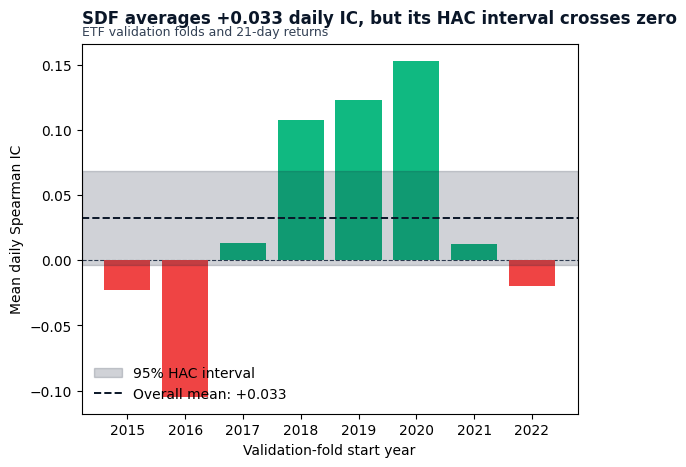

In [10]:
fig, ax = plt.subplots()
bar_colors = [
    COLORS["positive"] if value >= 0 else COLORS["negative"] for value in fold_ic["mean_daily_ic"]
]
ax.bar(
    fold_ic["start_year"].cast(pl.String).to_list(),
    fold_ic["mean_daily_ic"].to_list(),
    color=bar_colors,
)
ax.axhspan(
    daily_stats["ci_hac_lower"],
    daily_stats["ci_hac_upper"],
    color=COLORS["blue_light"],
    alpha=0.2,
    label="95% HAC interval",
)
zero_line(ax)
ax.axhline(
    daily_stats["mean_ic"],
    color=COLORS["blue"],
    linestyle="--",
    linewidth=1.4,
    label=f"Overall mean: {daily_stats['mean_ic']:+.3f}",
)
ax.set_xlabel("Validation-fold start year")
ax.set_ylabel("Mean daily Spearman IC")
ax.legend(frameon=False, loc="lower left")
add_message_title(
    ax,
    f"SDF averages {daily_stats['mean_ic']:+.3f} daily IC, but its HAC interval crosses zero",
    subtitle="ETF validation folds and 21-day returns",
)
display(
    fig,
    metadata={
        "image/png": {
            "alt": "Mean daily SDF rank IC by ETF validation fold, with the overall mean and "
            "95% HAC interval."
        }
    },
)
plt.close(fig)

In [11]:
display(
    Markdown(
        f"""
## Takeaways

- The direct 11-variable macro context uses exact ALFRED initial releases with a one-day
  availability lag. Both macro and complete modeling-input digests enter the training identity.
- The fixed checkpoint averages **{daily_stats["mean_ic"]:+.4f} daily IC** across
  {daily_stats["n_days"]:,} validation dates, with a 95% HAC interval of
  **[{daily_stats["ci_hac_lower"]:+.4f}, {daily_stats["ci_hac_upper"]:+.4f}]**
  (*t* = {daily_stats["t_hac"]:.2f}, *p* = {daily_stats["p_hac"]:.4f}). The interval crosses zero,
  so the result is statistically inconclusive.
- {positive_folds} folds have positive mean IC and {negative_folds} are negative, underscoring
  substantial regime dependence.
- Checkpoint {validation_max_epoch} has higher validation IC, but the fixed epoch-1280 rule prevents
  that diagnostic maximum from selecting the reported result.
- The backward-selected ETF universe and finalized-FRED financial features remain retrospective
  limitations.

**Next:** `12_causal_dml` tests whether the momentum signal has a stable causal interpretation;
`13_model_analysis` compares SDF with the other accepted model families. See Chapter 14,
Section 14.7.
"""
    )
)


## Takeaways

- The direct 11-variable macro context uses exact ALFRED initial releases with a one-day
  availability lag. Both macro and complete modeling-input digests enter the training identity.
- The fixed checkpoint averages **+0.0327 daily IC** across
  2,016 validation dates, with a 95% HAC interval of
  **[-0.0035, +0.0688]**
  (*t* = 1.77, *p* = 0.0764). The interval crosses zero,
  so the result is statistically inconclusive.
- 5 folds have positive mean IC and 3 are negative, underscoring
  substantial regime dependence.
- Checkpoint -2 has higher validation IC, but the fixed epoch-1280 rule prevents
  that diagnostic maximum from selecting the reported result.
- The backward-selected ETF universe and finalized-FRED financial features remain retrospective
  limitations.

**Next:** `12_causal_dml` tests whether the momentum signal has a stable causal interpretation;
`13_model_analysis` compares SDF with the other accepted model families. See Chapter 14,
Section 14.7.
